In [ ]:
from google.colab import files
files.upload()


# Dataset: Fake News Detection dataset from Kaggle
# Download from: https://www.kaggle.com/datasets/mahdimashayekhi/fake-news-detection-dataset
# Place the CSV file in the same directory as this notebook
df = pd.read_csv('fake_news.csv')





In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.metrics import(
 classification_report,
 confusion_matrix,
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 roc_curve

)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression


nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")

STOP_WORDS = set(stopwords.words("english"))
LEMM = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [7]:
# 2) Load dataset

df = pd.read_csv("fake_news_dataset.csv")

print(df.head())
print(df.info())
print(df.columns)
print("Shape:", df.shape)
print("Labels:", df["label"].unique())
print("Columns:", list(df.columns))

print("\nClass counts:")
print(df["label"].value_counts())
print("\nMissing values:\n", df.isna().sum())

# Keep only rows with text and label
df = df.dropna(subset=["text", "label"]).copy()




                                  title  \
0               Foreign Democrat final.   
1   To offer down resource great point.   
2          Himself church myself carry.   
3                  You unit its should.   
4  Billion believe employee summer how.   

                                                text        date    source  \
0  more tax development both store agreement lawy...  2023-03-10  NY Times   
1  probably guess western behind likely next inve...  2022-05-25  Fox News   
2  them identify forward present success risk sev...  2022-09-01       CNN   
3  phone which item yard Republican safe where po...  2023-02-07   Reuters   
4  wonder myself fact difficult course forget exa...  2023-04-03       CNN   

                 author    category label  
0          Paula George    Politics  real  
1           Joseph Hill    Politics  fake  
2        Julia Robinson    Business  fake  
3  Mr. David Foster DDS     Science  fake  
4         Austin Walker  Technology  fake  
<class '

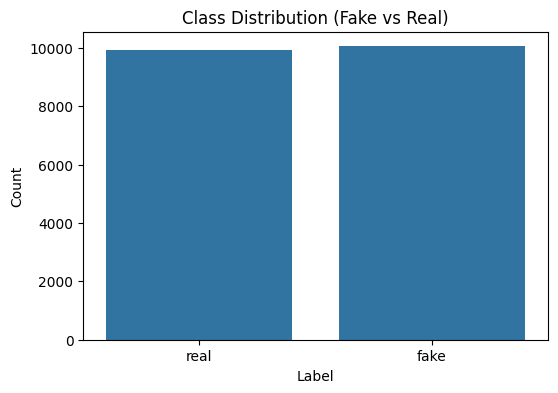

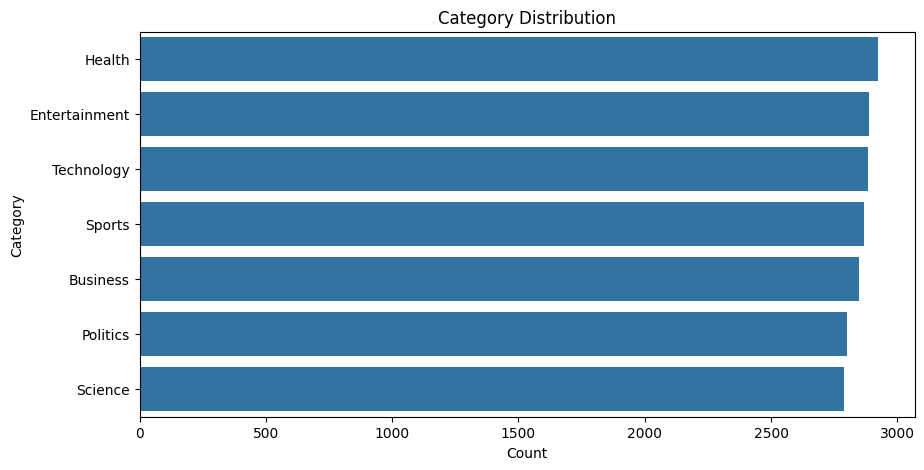

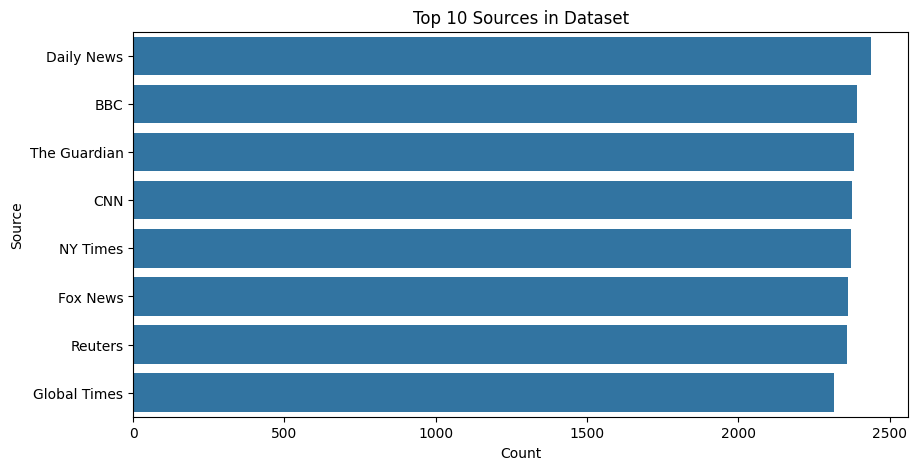


Text length summary (overall):
count    20000.000000
mean      1635.115900
std        192.855437
min       1223.000000
25%       1470.750000
50%       1634.000000
75%       1798.000000
max       2077.000000
Name: text_length, dtype: float64

Text length summary (by label):
         count         mean         std     min      25%     50%     75%  \
label                                                                      
fake   10056.0  1633.665573  194.141594  1223.0  1467.75  1631.0  1798.0   
real    9944.0  1636.582562  191.544605  1234.0  1474.00  1636.0  1799.0   

          max  
label          
fake   2054.0  
real   2077.0  


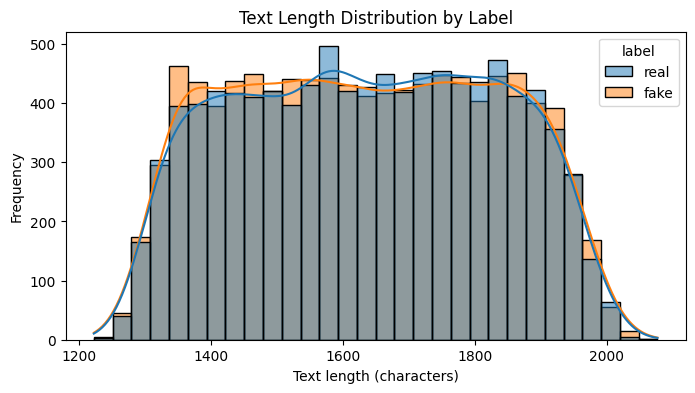

In [8]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution (Fake vs Real)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(10,5))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
plt.title("Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()


top_sources = df["source"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sources.values, y=top_sources.index)
plt.title("Top 10 Sources in Dataset")
plt.xlabel("Count")
plt.ylabel("Source")
plt.show()

df["text_length"] = df["text"].astype(str).apply(len)

print("\nText length summary (overall):")
print(df["text_length"].describe())

print("\nText length summary (by label):")
print(df.groupby("label")["text_length"].describe())

plt.figure(figsize=(8,4))
sns.histplot(data=df, x="text_length", hue="label", bins=30, kde=True)
plt.title("Text Length Distribution by Label")
plt.xlabel("Text length (characters)")
plt.ylabel("Frequency")
plt.show()



In [9]:
#4) preprocessing

def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [LEMM.lemmatize(t) for t in tokens]
    return " ".join(tokens)
df["cleaned_text"] = df["text"].apply(preprocess)

print(df[["text", "cleaned_text", "label"]].head())
print("cleaned_text created:", "cleaned_text" in df.columns)


                                                text  \
0  more tax development both store agreement lawy...   
1  probably guess western behind likely next inve...   
2  them identify forward present success risk sev...   
3  phone which item yard Republican safe where po...   
4  wonder myself fact difficult course forget exa...   

                                        cleaned_text label  
0  tax development store agreement lawyer hear ou...  real  
1  probably guess western behind likely next inve...  fake  
2  identify forward present success risk several ...  fake  
3  phone item yard republican safe police identif...  fake  
4  wonder fact difficult course forget exactly pa...  fake  
cleaned_text created: True



- Rule-based results -
Accuracy: 0.49985
              precision    recall  f1-score   support

        fake       0.52      0.09      0.15     10056
        real       0.50      0.92      0.65      9944

    accuracy                           0.50     20000
   macro avg       0.51      0.50      0.40     20000
weighted avg       0.51      0.50      0.40     20000



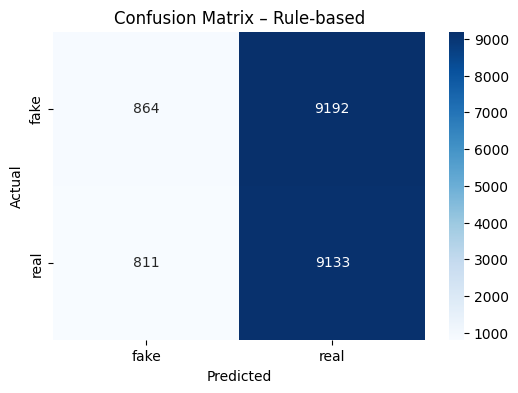

In [10]:
# 5) Rule-based method
fake_keywords = [
    "shocking", "unbelievable", "secret", "miracle", "exposed",
    "breaking", "truth", "scandal", "conspiracy", "wont believe"
]

real_indicators = [
    "reported", "official", "confirmed", "statement", "evidence", "study"
]

def rule_based_classifier(cleaned_text):
    text = cleaned_text if isinstance(cleaned_text, str) else ""
    fake_score = sum(1 for kw in fake_keywords if kw in text)
    real_score = sum(1 for kw in real_indicators if kw in text)

    # Predict fake only if fake signals outweigh real signals
    return "fake" if fake_score > real_score else "real"

labels_lower = set(df["label"].astype(str).str.lower().unique())
if labels_lower.issubset({"fake", "real"}):
    df["rule_pred"] = df["cleaned_text"].apply(rule_based_classifier)
    y_true_rule = df["label"].astype(str).str.lower()
    y_pred_rule = df["rule_pred"].astype(str).str.lower()

    print("\n- Rule-based results -")
    print("Accuracy:", accuracy_score(y_true_rule, y_pred_rule))
    print(classification_report(y_true_rule, y_pred_rule, zero_division=0))

    cm_rule = confusion_matrix(y_true_rule, y_pred_rule, labels=["fake", "real"])
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_rule, annot=True, fmt="d", cmap="Blues",
                xticklabels=["fake", "real"], yticklabels=["fake", "real"])
    plt.title("Confusion Matrix – Rule-based")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
else:
    print("\nRule-based evaluation skipped: your labels are not exactly 'fake'/'real'.")
    print("Your unique labels:", df["label"].unique())
    print("Tell me what 0/1 means (if numeric) and I will map it correctly.")


In [11]:
# 6) ML: Train/test split

X = df["cleaned_text"].astype(str)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# 7) TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [13]:
# 8) ML Model 1: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)



--- Naive Bayes (TF-IDF) ---
Accuracy : 0.506
Precision: 0.505
Recall   : 0.506
F1-score : 0.501

Classification report:
               precision    recall  f1-score   support

        fake       0.51      0.60      0.55      2011
        real       0.50      0.41      0.45      1989

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.50      4000
weighted avg       0.51      0.51      0.50      4000



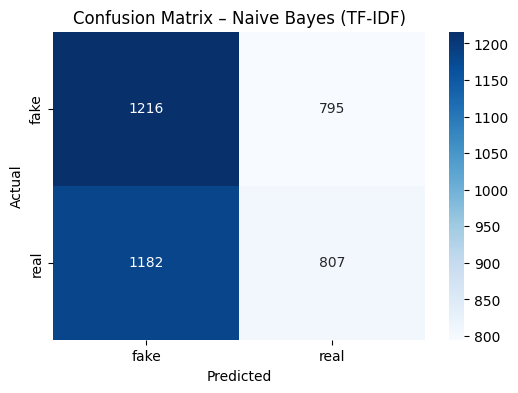


--- Logistic Regression (TF-IDF) ---
Accuracy : 0.510
Precision: 0.510
Recall   : 0.510
F1-score : 0.510

Classification report:
               precision    recall  f1-score   support

        fake       0.51      0.52      0.52      2011
        real       0.51      0.50      0.50      1989

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000



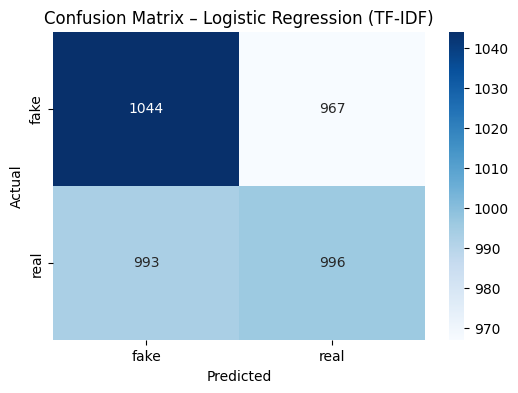


Model comparison:


,Model,Accuracy,Precision,Recall,F1
1,Logistic Regression (TF-IDF),0.51000,0.509967,0.51000,0.509962
0,Naive Bayes (TF-IDF),0.50575,0.505426,0.50575,0.500809


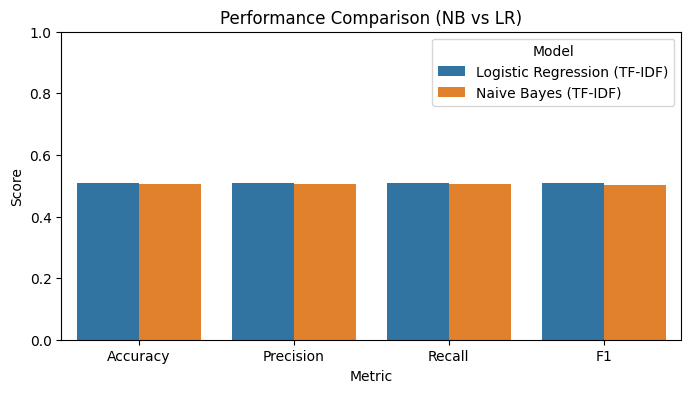

In [14]:
# 9) ML Model 2: Logistic Regression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]


def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print("\nClassification report:\n", classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

results = []
results.append(evaluate("Naive Bayes (TF-IDF)", y_test, y_pred_nb))
results.append(evaluate("Logistic Regression (TF-IDF)", y_test, y_pred_lr))

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\nModel comparison:")
display(results_df)

plt.figure(figsize=(8,4))
sns.barplot(data=results_df.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1"]),
            x="variable", y="value", hue="Model")
plt.ylim(0,1)
plt.title("Performance Comparison (NB vs LR)")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.show()




Logistic Regression ROC-AUC (positive='fake'): 0.507


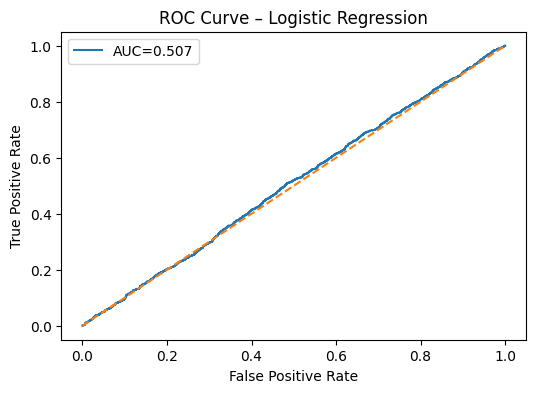

In [15]:
# 10) ROC curve (binary only)

classes = list(lr.classes_)
if len(classes) == 2 and hasattr(lr, "predict_proba"):
    # Choose positive class: if 'fake' exists, use it; otherwise second class
    pos_label = None
    for c in classes:
        if str(c).lower() == "fake":
            pos_label = c
    if pos_label is None:
        pos_label = classes[1]

    y_test_bin = (y_test == pos_label).astype(int)
    lr_proba = lr.predict_proba(X_test_tfidf)[:, classes.index(pos_label)]
    auc = roc_auc_score(y_test_bin, lr_proba)
    fpr, tpr, _ = roc_curve(y_test_bin, lr_proba)

    print(f"\nLogistic Regression ROC-AUC (positive='{pos_label}'): {auc:.3f}")
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title("ROC Curve – Logistic Regression")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

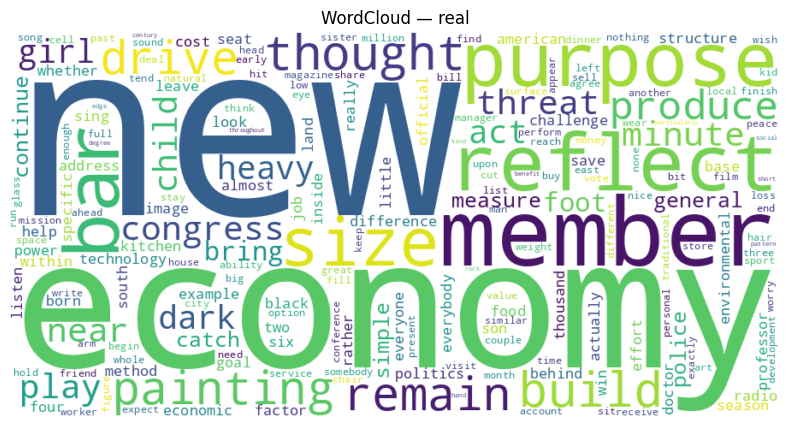

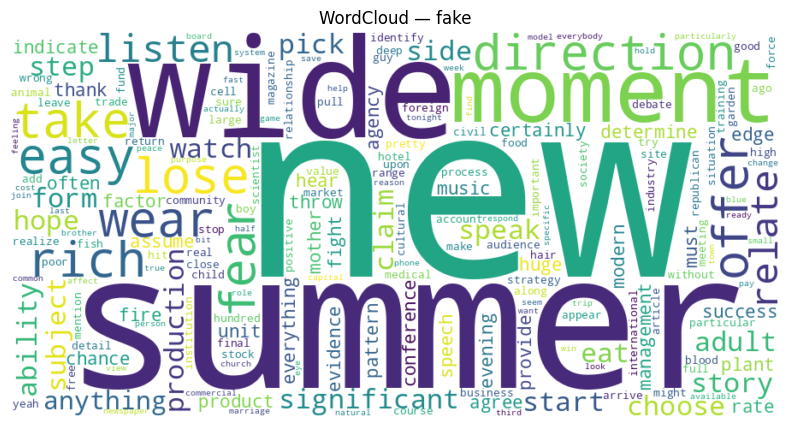


Pipeline completed successfully.


In [16]:


from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 11) WordClouds by label
for lab in df["label"].unique():
    text_blob = " ".join(df.loc[df["label"] == lab, "cleaned_text"].astype(str).tolist())

    if len(text_blob.strip()) < 50:
        print(f"Not enough text for label: {lab}")
        continue

    wc = WordCloud(width=900, height=450, background_color="white").generate(text_blob)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — {lab}")
    plt.show()

print("\nPipeline completed successfully.")


In [17]:
y_pred_lr = lr.predict(X_test_tfidf)

samples_df = df.iloc[y_test.index].copy()   # works if y_test kept index
samples_df["predicted"] = y_pred_lr
samples_df["correct"] = samples_df["label"] == samples_df["predicted"]
samples_df["snippet"] = samples_df["cleaned_text"].astype(str).str[:140] + "..."

display(samples_df[["snippet", "label", "predicted", "correct"]].head(10))


,snippet,label,predicted,correct
12334,feeling investment compare left necessary pick...,real,real,True
4143,radio mind capital senior simply feeling churc...,fake,fake,True
3353,reduce realize reality special price case fath...,fake,real,False
8775,everything whole protect truth least whose his...,real,fake,False
2368,turn provide born prevent arrive ahead hold st...,fake,fake,True
14569,receive begin main education prove ask turn po...,fake,fake,True
18922,behind skill notice amount war eight lose old ...,real,fake,False
17384,special war high daughter continue suggest peo...,fake,real,False
18899,hair bar radio end close assume rise tonight s...,real,real,True
892,news however even skin party admit play wester...,real,fake,False
